# 1 Installing the YOLOv8 Environment

To start off with YOLOv8 we first clone the YOLOv8 repository and install dependencies. This will set up our programming environment to be ready to running object detection training and inference commands.

In [1]:
# Clone repository
!git clone https://github.com/ultralytics/ultralytics

# Navigate to the cloned directory
%cd ultralytics

# Install the package in editable mode for development
!pip install -e .

C:\Users\CP1\Documents\GitHub\Itemized-Billing\ultralytics


fatal: destination path 'ultralytics' already exists and is not an empty directory.


Obtaining file:///C:/Users/CP1/Documents/GitHub/Itemized-Billing/ultralytics
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.0.165
    Uninstalling ultralytics-8.0.165:
      Successfully uninstalled ultralytics-8.0.165
  Running setup.py develop for ultralytics


# 2 Import Libraries

In [1]:
import torch
print('torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))
from ultralytics import YOLO

import yaml
import glob
from IPython.display import Image, display
from IPython.core.magic import register_line_cell_magic

from ImageDeskewer import Deskew

torch 1.13.1+cu116 _CudaDeviceProperties(name='NVIDIA GeForce RTX 3090', major=8, minor=6, total_memory=24575MB, multi_processor_count=82)


In [3]:
%cd ..

# Open and read the YAML file
with open('config.yaml', 'r') as file:
    yaml_data = yaml.safe_load(file)

yaml_data

C:\Users\CP1\Documents\GitHub\Itemized-Billing


{'path': 'C:/Users/CP1/Documents/GitHub/Itemized-Billing/HB-yolo-1.1',
 'train': 'train.txt',
 'val': 'valid.txt',
 'nc': 1,
 'names': ['table']}

In [4]:
# Define number of classes based on YAML
with open('config.yaml', 'r') as stream:
    num_classes = str(yaml.safe_load(stream)['nc'])

print(f'Number of class: {num_classes}')

Number of class: 1


In [6]:
import os

current_directory = os.getcwd()
print("Current Directory:", current_directory)

Current Directory: C:\Users\CP1\Documents\GitHub\Itemized-Billing


# 3 Train YOLOv8

In [7]:
model = YOLO('yolov8s.yaml')  # build a new model from scratch

results = model.train(data='config.yaml', epochs=50, workers=2)  # train the model


                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

# 4 Evaluate the model

In [37]:
results.results_dict

{'metrics/precision(B)': 0.9985087421385683,
 'metrics/recall(B)': 1.0,
 'metrics/mAP50(B)': 0.995,
 'metrics/mAP50-95(B)': 0.9663622023494376,
 'fitness': 0.9692259821144938}

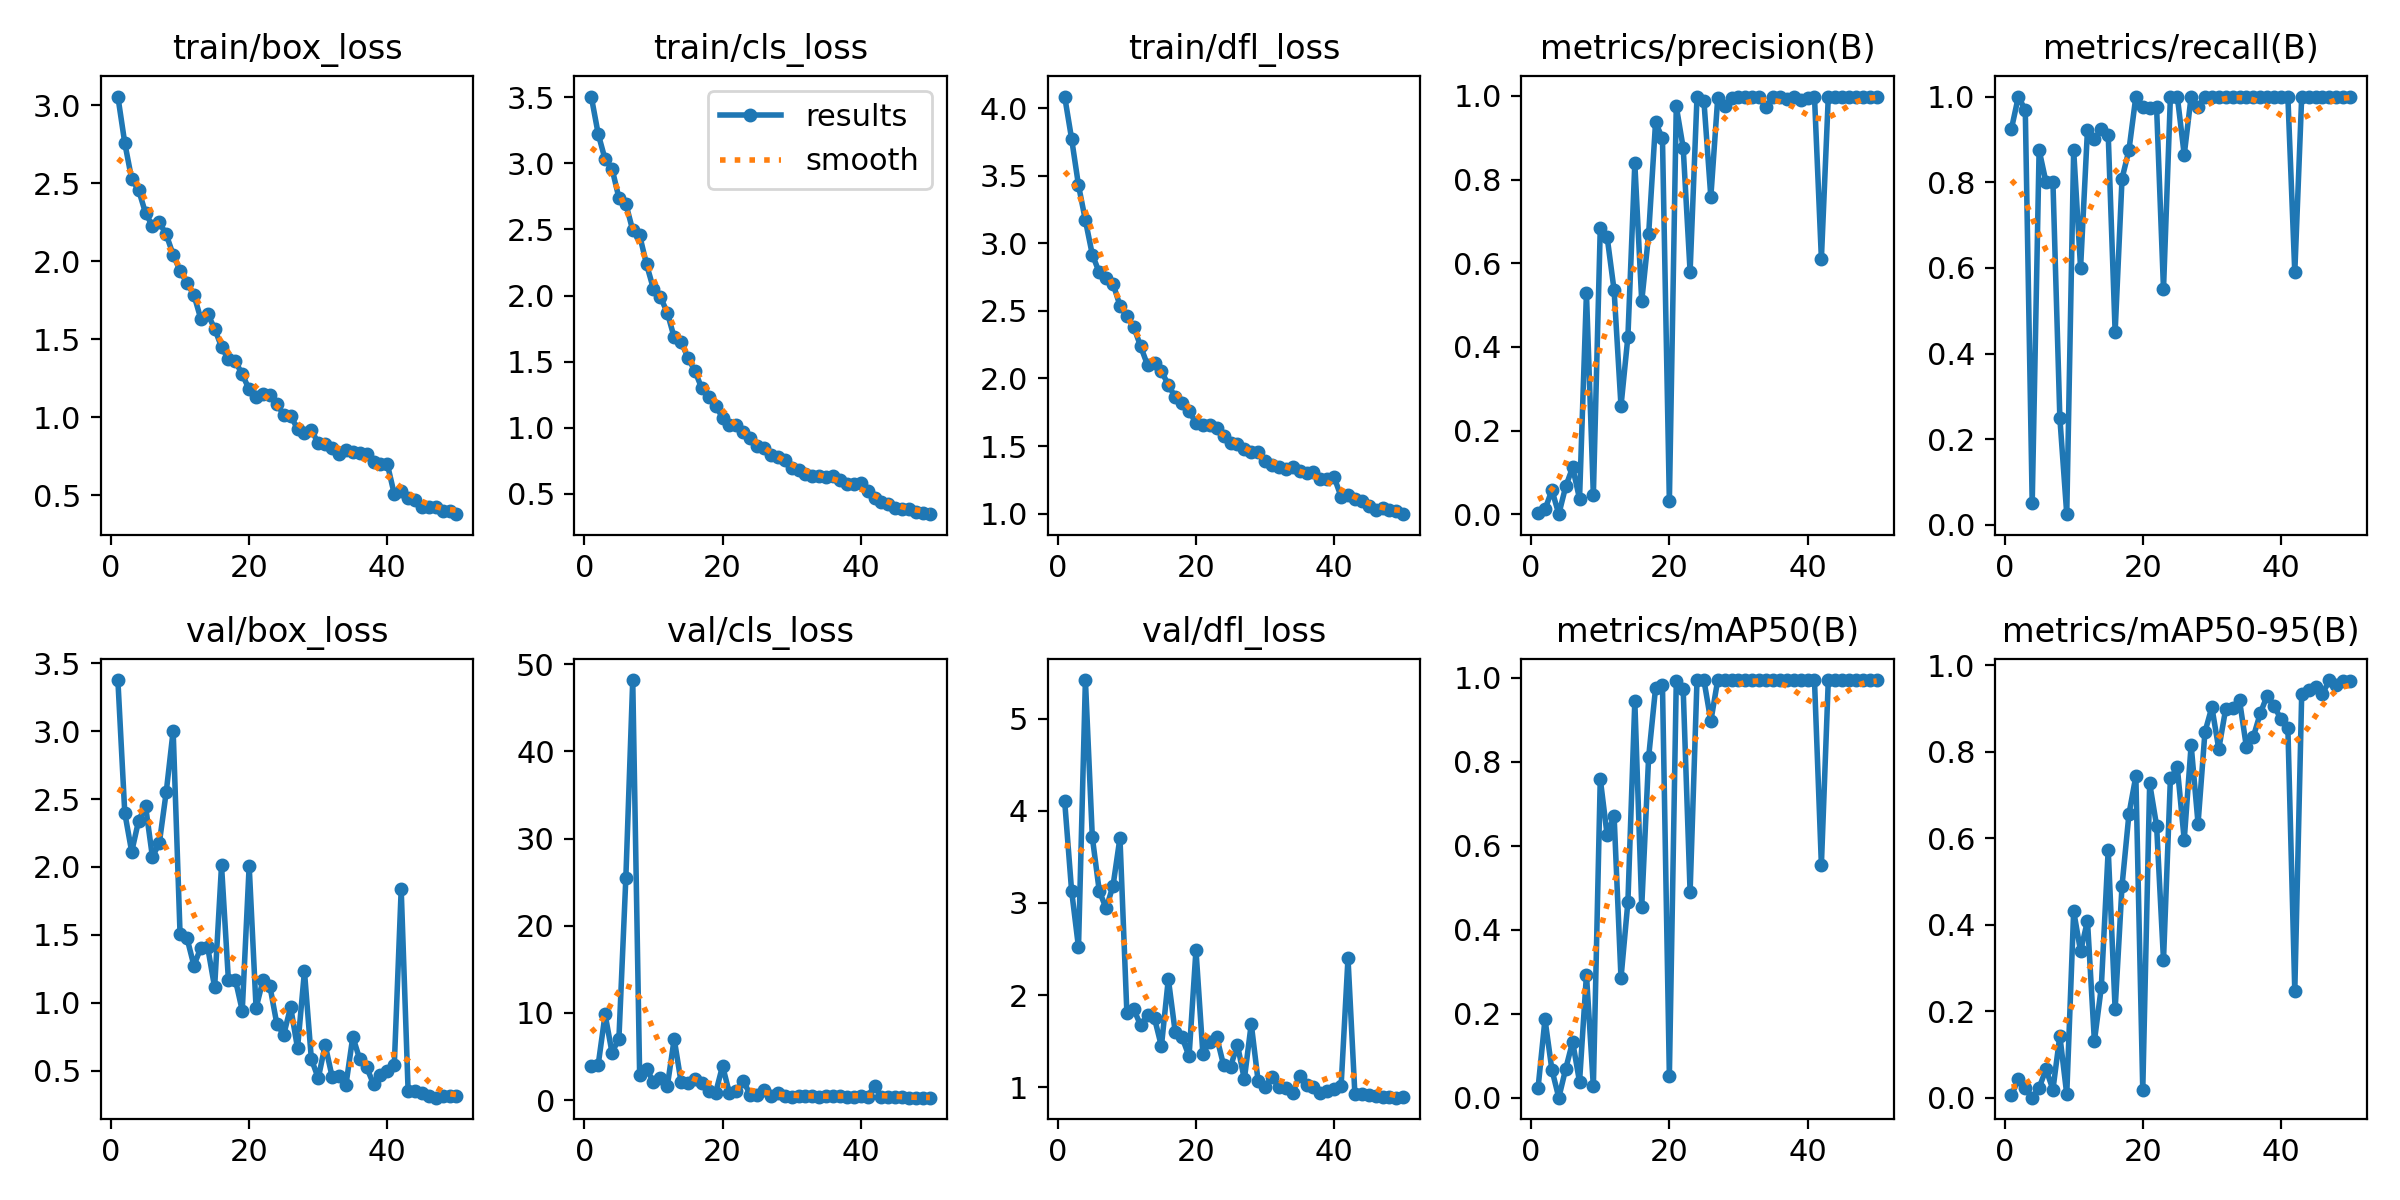

In [22]:
# We can also output some older school graphs if the tensor board isn't working for whatever reason...
Image(filename=f'{str(results.save_dir)}/results.png', width=1000)

## 4.1 Visualize the Training Data

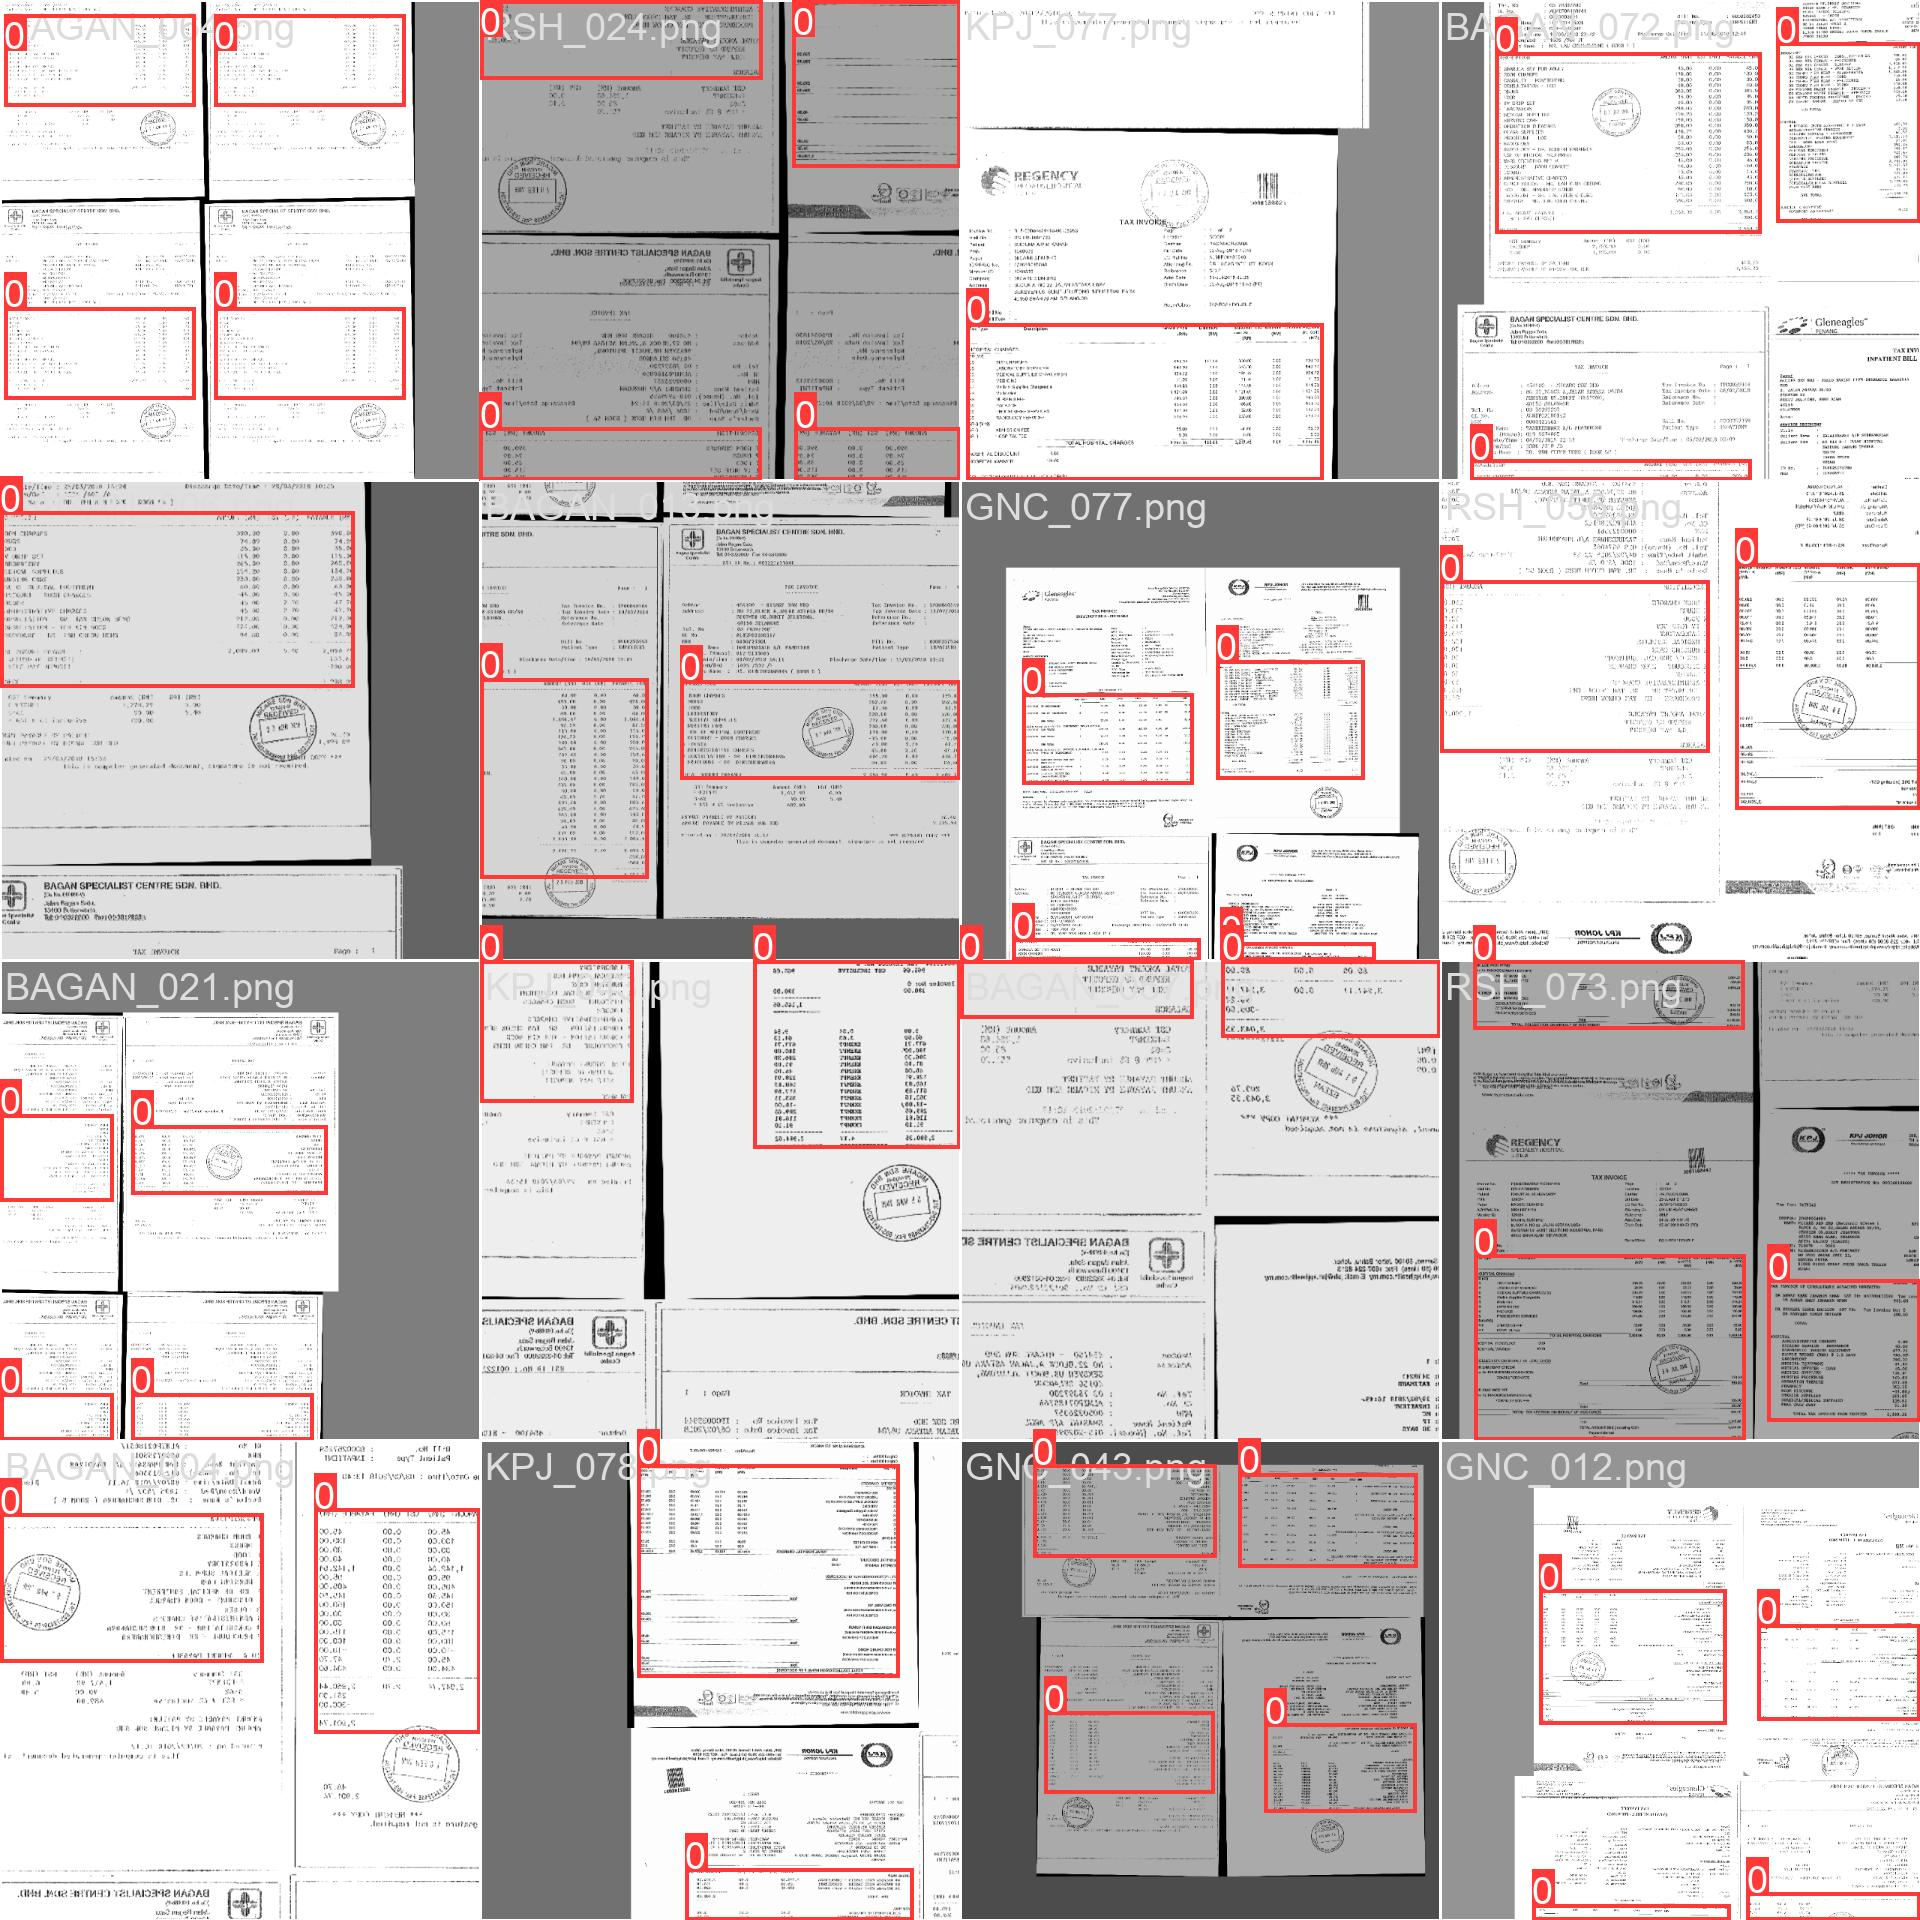

In [55]:
Image(filename=f'{str(results.save_dir)}/train_batch0.jpg', width=900)

## 4.2 Visualize the Labels of Validating Data

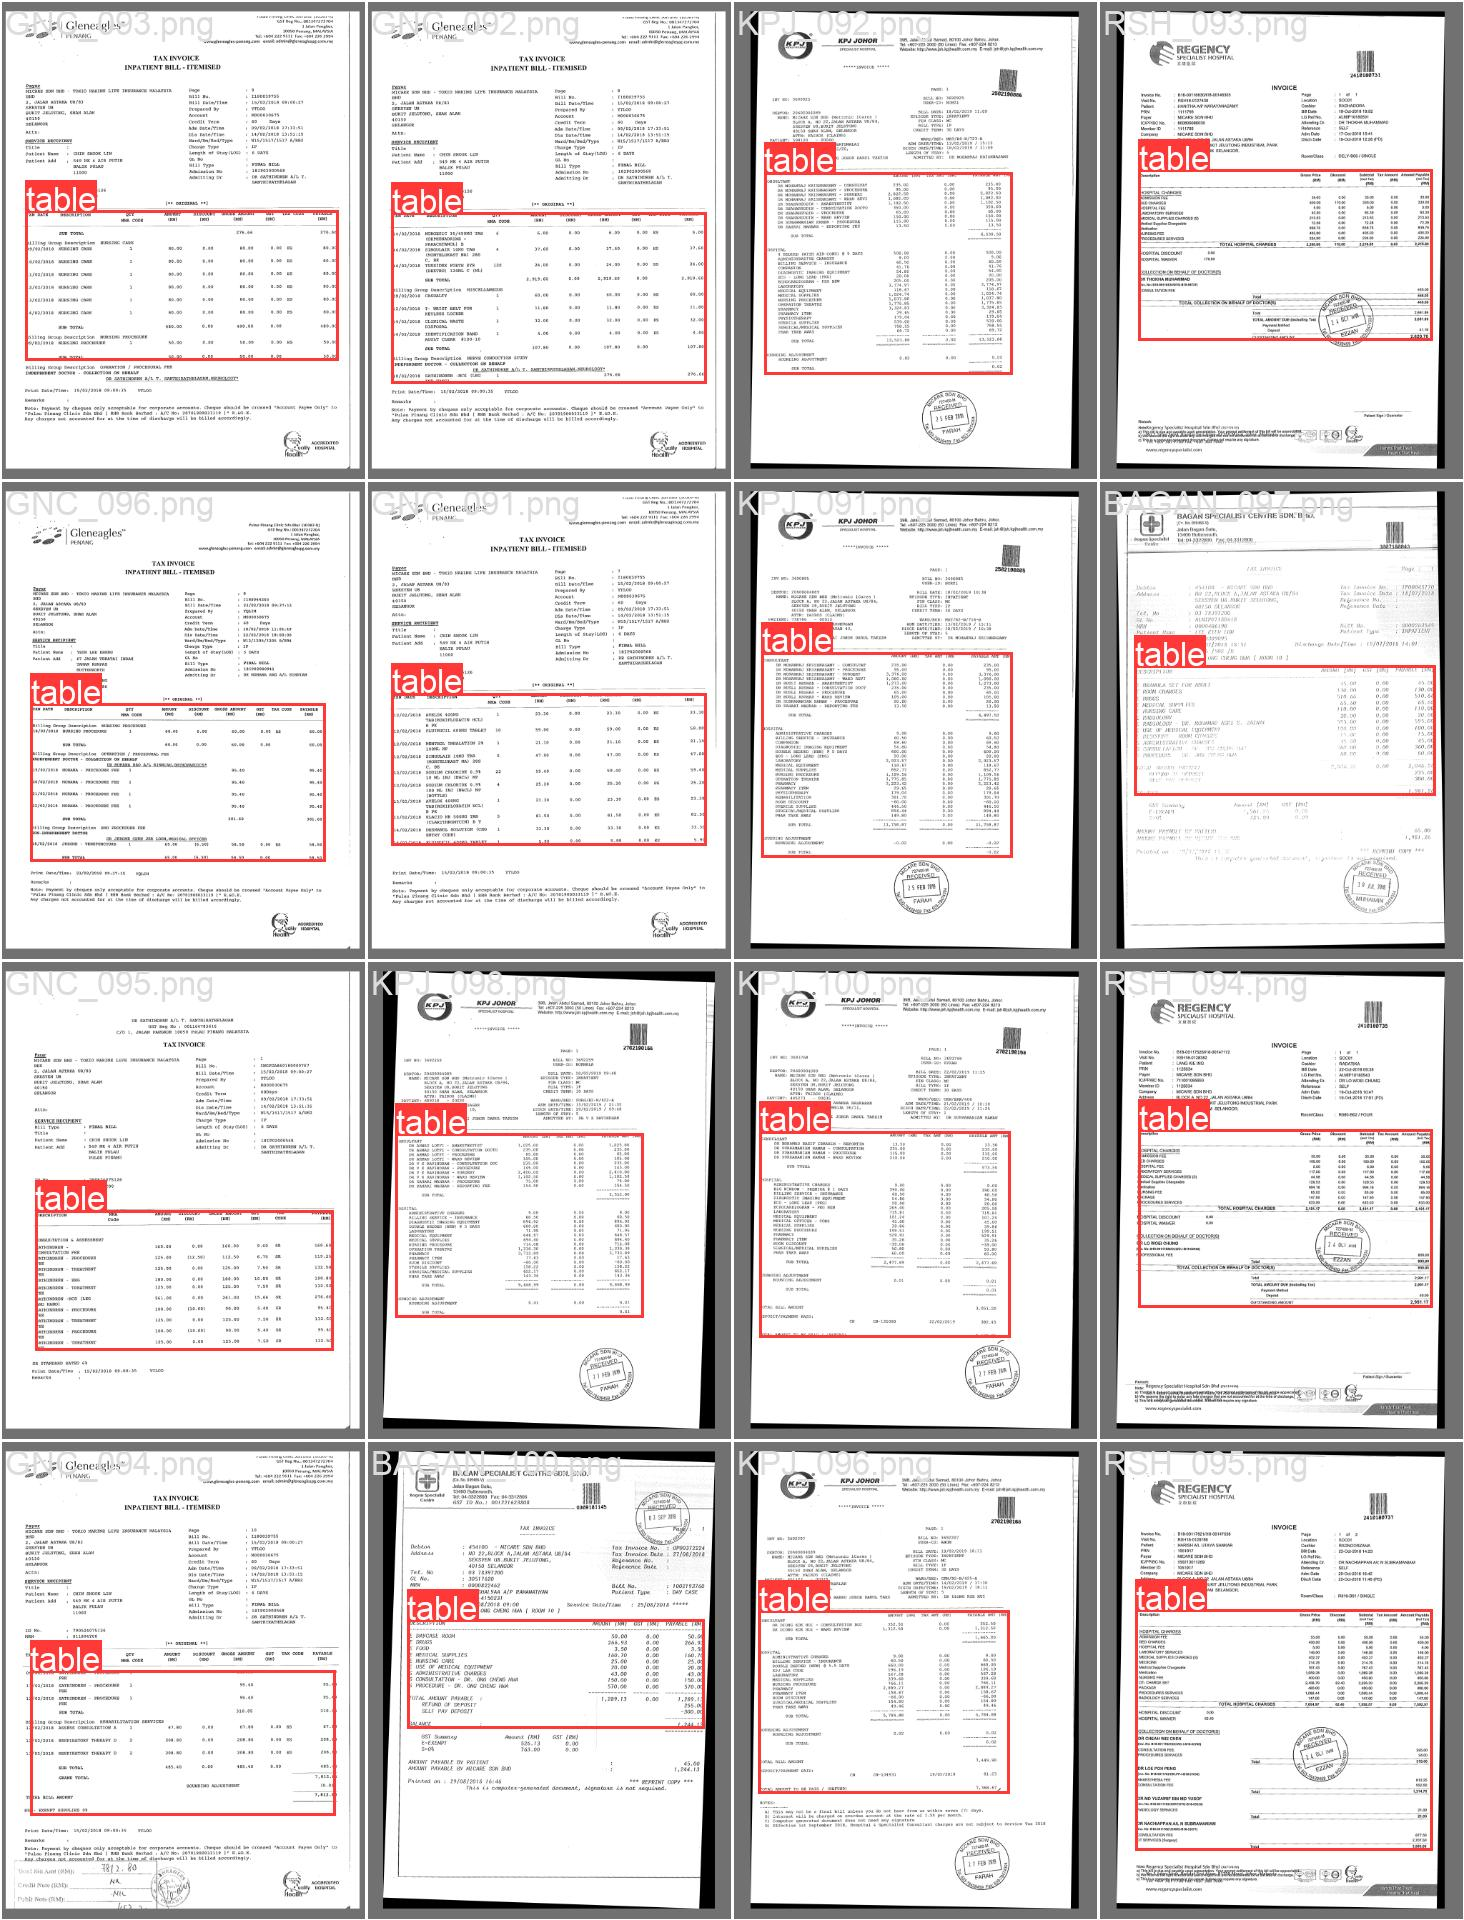

In [59]:
Image(filename=f'{str(results.save_dir)}/val_batch0_labels.jpg', width=900)

## 4.3 Visualize the Predicted Testing Data

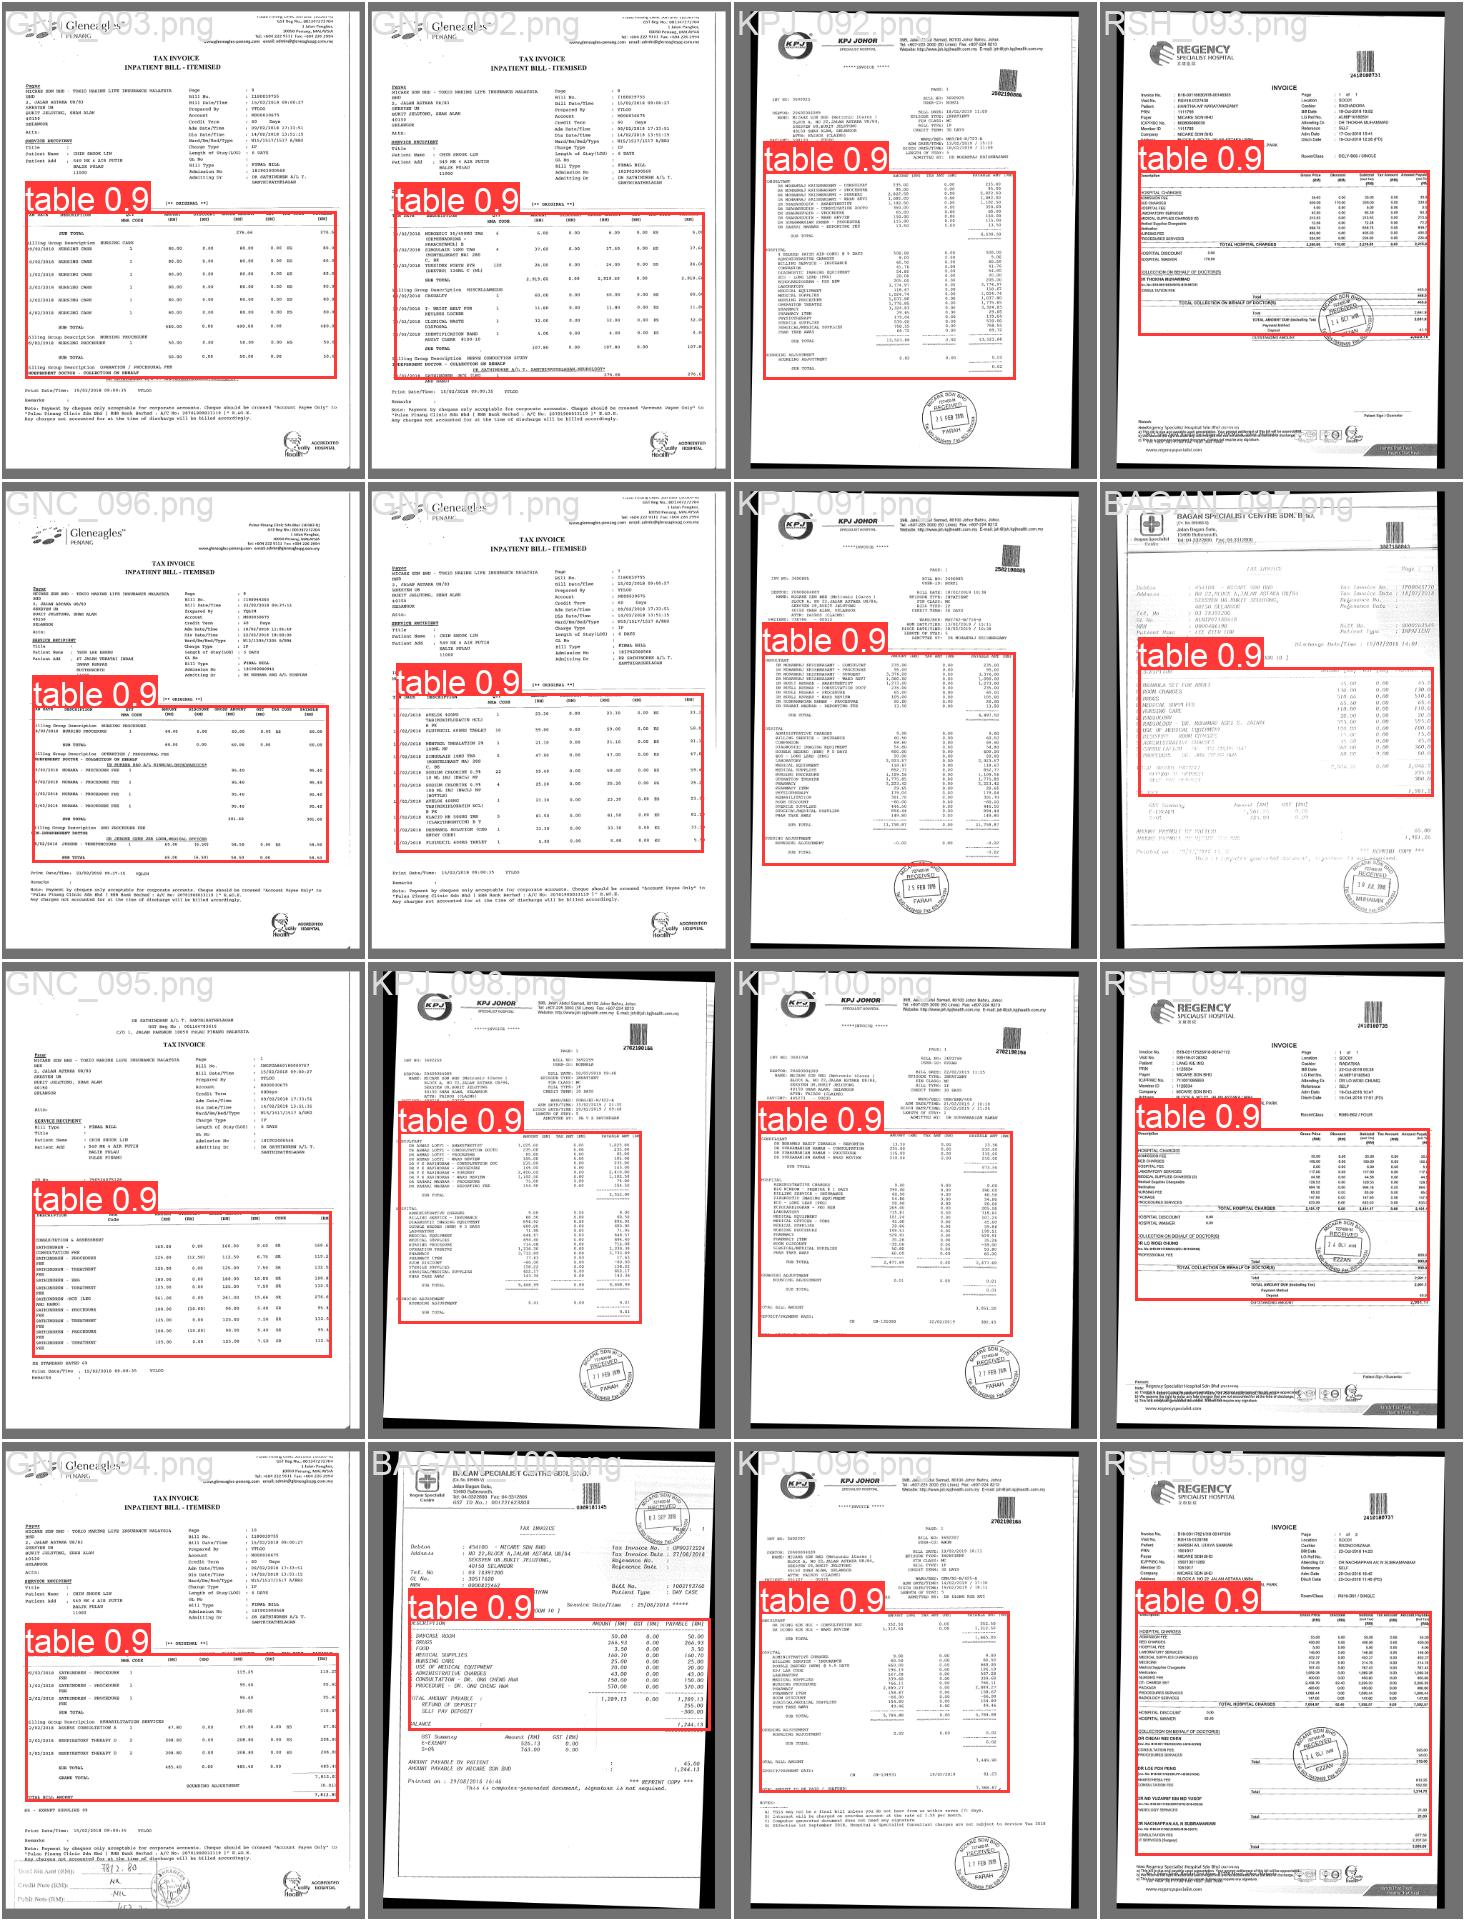

In [58]:
Image(filename=f'{str(results.save_dir)}/val_batch0_pred.jpg', width=900)

# 5 Run Inference  With Trained Weights
Run inference with a pretrained checkpoint on contents of `test/images` folder downloaded from Roboflow.


In [64]:
source = 'CVAT/Testing Set'
model = YOLO(f'{str(results.save_dir)}/weights/best.pt')

# deskewer = Deskew(source)
# deskewer.processor()

prediction = model.predict(source=source, save=True)
prediction

1. CVAT/Testing Set\TEST_BAGAN_001.png
2. CVAT/Testing Set\TEST_BAGAN_002.png
3. CVAT/Testing Set\TEST_BAGAN_003.png
4. CVAT/Testing Set\TEST_BAGAN_004.png
5. CVAT/Testing Set\TEST_BAGAN_005.png
6. CVAT/Testing Set\TEST_BAGAN_006.png
7. CVAT/Testing Set\TEST_BAGAN_007.png
8. CVAT/Testing Set\TEST_BAGAN_008.png
9. CVAT/Testing Set\TEST_BAGAN_009.png
10. CVAT/Testing Set\TEST_BAGAN_010.png
11. CVAT/Testing Set\TEST_GNC_001.png
12. CVAT/Testing Set\TEST_GNC_002.png
13. CVAT/Testing Set\TEST_GNC_003.png
14. CVAT/Testing Set\TEST_GNC_004.png
15. CVAT/Testing Set\TEST_GNC_005.png
16. CVAT/Testing Set\TEST_GNC_006.png
17. CVAT/Testing Set\TEST_GNC_007.png
18. CVAT/Testing Set\TEST_GNC_008.png
19. CVAT/Testing Set\TEST_GNC_009.png
20. CVAT/Testing Set\TEST_GNC_010.png
21. CVAT/Testing Set\TEST_KPJ_001.png
22. CVAT/Testing Set\TEST_KPJ_002.png
23. CVAT/Testing Set\TEST_KPJ_003.png
24. CVAT/Testing Set\TEST_KPJ_004.png
25. CVAT/Testing Set\TEST_KPJ_005.png
26. CVAT/Testing Set\TEST_KPJ_006.png
2

In [3]:
prediction


image 1/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\CVAT\Testing Set\TEST_BAGAN_001.png: 640x480 1 table, 31.2ms
image 2/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\CVAT\Testing Set\TEST_BAGAN_002.png: 640x480 1 table, 26.2ms
image 3/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\CVAT\Testing Set\TEST_BAGAN_003.png: 640x480 1 table, 23.7ms
image 4/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\CVAT\Testing Set\TEST_BAGAN_004.png: 640x480 1 table, 25.5ms
image 5/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\CVAT\Testing Set\TEST_BAGAN_005.png: 640x480 1 table, 12.5ms
image 6/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\CVAT\Testing Set\TEST_BAGAN_006.png: 640x480 1 table, 31.2ms
image 7/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\CVAT\Testing Set\TEST_BAGAN_007.png: 640x480 1 table, 21.2ms
image 8/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\CVAT\Testing Set\TEST_BAGAN_008.png: 640x480 1 table, 31.7ms
image 9/40 C:\Users\CP1\Documents\GitHub\Itemiz

In [9]:
# Display inference on ALL test images

for imageName in glob.glob('/content/yolov5/runs/detect/exp2/*.jpg'): #assuming JPG
    display(Image(filename=imageName))
    print("\n")

Ultralytics YOLOv8.0.165  Python-3.10.10 torch-1.13.1+cu116 CPU (Intel Xeon W-2235 3.80GHz)

PyTorch: starting from 'runs\detect\train5\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.4 MB)

TorchScript: starting export with torch 1.13.1+cu116...
TorchScript: export success  2.6s, saved as 'runs\detect\train5\weights\best.torchscript' (42.9 MB)

Export complete (5.4s)
Results saved to C:\Users\CP1\Documents\GitHub\Itemized-Billing\runs\detect\train5\weights
Predict:         yolo predict task=detect model=runs\detect\train5\weights\best.torchscript imgsz=640 
Validate:        yolo val task=detect model=runs\detect\train5\weights\best.torchscript imgsz=640 data=config.yaml 
Visualize:       https://netron.app


'runs\\detect\\train5\\weights\\best.torchscript'